<a href="https://colab.research.google.com/github/SalehMousavi/TumorClassifier/blob/main/BaselineModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing all libraries here.


In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split, TensorDataset
import torch.nn as nn
import torch.optim as optim
import time
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, auc, roc_curve
from sklearn.preprocessing import StandardScaler
import numpy as np
from PIL import Image
import os
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from sklearn.svm import SVC

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def get_data(data_loader):
    all_images = []
    all_labels = []

    total_batches = len(data_loader)
    for i, (images, labels) in enumerate(data_loader):
        # if(i == (total_batches - 2)):
        #   break
        images = images.view(images.size(0), -1).to(device)  # Flatten and move to GPU
        labels = labels.to(device)
        all_images.append(images)
        all_labels.append(labels)
        print(f"Progress: {i + 1}/{total_batches}")

    all_images = torch.cat(all_images, dim=0)
    all_labels = torch.cat(all_labels, dim=0)

    return all_images, all_labels

# Define transformations
transform = transforms.Compose([
    transforms.Resize((128, 128)),  # Resize images to 64x64
    transforms.ToTensor(),  # Convert images to PyTorch tensors
])

In [ ]:
val_folder = '/content/gdrive/MyDrive/APS360/DataMultiClass/DatasetSplit/val'
test_folder = '/content/gdrive/MyDrive/APS360/DataMultiClass/TestProcessed'
train_folder = '/content/gdrive/MyDrive/APS360/DataMultiClass/Augmented'
train_data = torchvision.datasets.ImageFolder(root=train_folder, transform=transform)

In [ ]:
# Create DataLoaders
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

batch_size = 256  # Adjust based on available memory
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=False)
# val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)

# Extract training and validation data
train_images, train_labels = get_data(train_loader)
# val_images, val_labels = get_batched_data(val_loader)

Progress: 1/70
Progress: 2/70
Progress: 3/70
Progress: 4/70
Progress: 5/70
Progress: 6/70
Progress: 7/70
Progress: 8/70
Progress: 9/70
Progress: 10/70
Progress: 11/70
Progress: 12/70
Progress: 13/70
Progress: 14/70
Progress: 15/70
Progress: 16/70
Progress: 17/70
Progress: 18/70
Progress: 19/70
Progress: 20/70
Progress: 21/70
Progress: 22/70
Progress: 23/70
Progress: 24/70
Progress: 25/70
Progress: 26/70
Progress: 27/70
Progress: 28/70
Progress: 29/70
Progress: 30/70
Progress: 31/70
Progress: 32/70
Progress: 33/70
Progress: 34/70
Progress: 35/70
Progress: 36/70
Progress: 37/70
Progress: 38/70
Progress: 39/70
Progress: 40/70
Progress: 41/70
Progress: 42/70
Progress: 43/70
Progress: 44/70
Progress: 45/70
Progress: 46/70
Progress: 47/70
Progress: 48/70
Progress: 49/70
Progress: 50/70
Progress: 51/70
Progress: 52/70
Progress: 53/70
Progress: 54/70
Progress: 55/70
Progress: 56/70
Progress: 57/70
Progress: 58/70
Progress: 59/70
Progress: 60/70
Progress: 61/70
Progress: 62/70
Progress: 63/70
P

In [ ]:
from sklearn import svm
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, auc, roc_curve
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, auc, roc_curve

In [ ]:
train_images = train_images.cpu().numpy()
train_labels = train_labels.cpu().numpy()

In [ ]:
svm_classifier = svm.SVC(kernel='linear', C=1.0)
svm_classifier.fit(train_images, train_labels)
print("SVM training complete!")

SVM training complete!


In [ ]:
val_data = torchvision.datasets.ImageFolder(root=val_folder, transform=transform)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)

# Extract training and validation data
val_images, val_labels = get_data(train_loader)

Progress: 1/70
Progress: 2/70
Progress: 3/70
Progress: 4/70
Progress: 5/70
Progress: 6/70
Progress: 7/70
Progress: 8/70
Progress: 9/70
Progress: 10/70
Progress: 11/70
Progress: 12/70
Progress: 13/70
Progress: 14/70
Progress: 15/70
Progress: 16/70
Progress: 17/70
Progress: 18/70
Progress: 19/70
Progress: 20/70
Progress: 21/70
Progress: 22/70
Progress: 23/70
Progress: 24/70
Progress: 25/70
Progress: 26/70
Progress: 27/70
Progress: 28/70
Progress: 29/70
Progress: 30/70
Progress: 31/70
Progress: 32/70
Progress: 33/70
Progress: 34/70
Progress: 35/70
Progress: 36/70
Progress: 37/70
Progress: 38/70
Progress: 39/70
Progress: 40/70
Progress: 41/70
Progress: 42/70
Progress: 43/70
Progress: 44/70
Progress: 45/70
Progress: 46/70
Progress: 47/70
Progress: 48/70
Progress: 49/70
Progress: 50/70
Progress: 51/70
Progress: 52/70
Progress: 53/70
Progress: 54/70
Progress: 55/70
Progress: 56/70
Progress: 57/70
Progress: 58/70
Progress: 59/70
Progress: 60/70
Progress: 61/70
Progress: 62/70
Progress: 63/70
P

In [ ]:
# Validate the SVM
val_images = val_images.cpu().numpy()
val_labels = val_labels.cpu().numpy()
val_predictions = svm_classifier.predict(val_images)
val_accuracy = (val_predictions == val_labels).mean()
print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")

Validation Accuracy: 99.98%


In [ ]:
test_folder = '/content/gdrive/MyDrive/APS360/DataMultiClass/TestProcessed'
test_data = torchvision.datasets.ImageFolder(root=test_folder, transform=transform)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)
test_images, test_labels = get_data(test_loader)

Progress: 1/6
Progress: 2/6
Progress: 3/6
Progress: 4/6
Progress: 5/6
Progress: 6/6


In [ ]:
from sklearn import svm
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, auc, roc_curve
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, auc, roc_curve

In [ ]:
svm_classifier = svm.SVC(kernel='linear', C=1.0)  # Linear kernel SVM
svm_classifier.fit(train_images, train_labels)

In [ ]:
val_images, val_labels = get_data(val_data)

In [ ]:
#Get validation performance
val_predictions = svm_classifier.predict(val_images)
val_accuracy = accuracy_score(val_labels, val_predictions)
val_precision = precision_score(val_labels, val_predictions, average='weighted')
val_recall = recall_score(val_labels, val_predictions, average='weighted')
val_f1 = f1_score(val_labels, val_predictions, average='weighted')
print(f"Validation Accuracy: {val_accuracy}")
print(f"Validation Precision: {val_precision}")
print(f"Validation Recall: {val_recall}")
print(f"Validation F1 Score: {val_f1}")

In [ ]:
test_images = test_images.cpu().numpy()
test_labels = test_labels.cpu().numpy()

In [ ]:
#Get test performance
test_predictions = svm_classifier.predict(test_images)
test_accuracy = accuracy_score(test_labels, test_predictions)
test_precision = precision_score(test_labels, test_predictions, average='weighted')
test_recall = recall_score(test_labels, test_predictions, average='weighted')
test_f1 = f1_score(test_labels, test_predictions, average='weighted')
print(f"Test Accuracy: {test_accuracy}")
print(f"Test Precision: {test_precision}")
print(f"Test Recall: {test_recall}")
print(f"Test F1 Score: {test_f1}")


Test Accuracy: 0.5118230358504958
Test Precision: 0.5539024508883373
Test Recall: 0.5118230358504958
Test F1 Score: 0.46459028663079266


In [ ]:
test_accuracy = accuracy_score(test_labels, test_predictions)
test_precision = precision_score(test_labels, test_predictions, average=None)
test_recall = recall_score(test_labels, test_predictions, average=None)
test_f1 = f1_score(test_labels, test_predictions, average=None)

# Print individual class metrics
print(f"Test Accuracy: {test_accuracy}")
print(f"Precision for each class: {test_precision}")
print(f"Recall for each class: {test_recall}")
print(f"F1 Score for each class: {test_f1}")

Test Accuracy: 0.5118230358504958
Precision for each class: [0.46383467 0.38518519 0.68421053 0.71727749]
Recall for each class: [0.99753086 0.16993464 0.26       0.45666667]
F1 Score for each class: [0.63322884 0.23582766 0.37681159 0.55804481]


Use a seperate function for running the entire pipeline of the baseline model with predefined dataset.


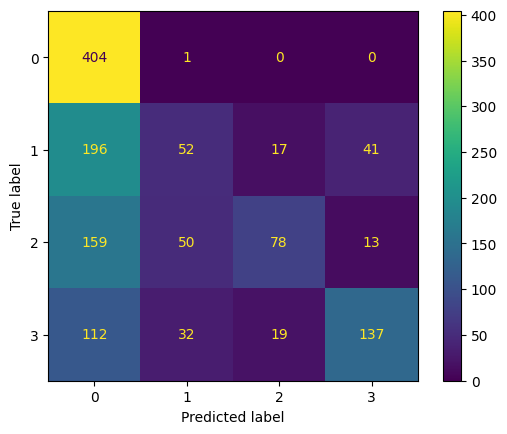

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Compute confusion matrix
conf_matrix = confusion_matrix(test_labels, test_predictions)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=svm_classifier.classes_)
disp.plot(cmap='viridis')  # You can change the colormap as needed


In [ ]:
!pip install joblib


In [ ]:
import joblib

# Save the trained model to a file
joblib.dump(svm_classifier, '/content/gdrive/MyDrive/APS360/DataMultiClass/svm_model128x128.pkl')

['/content/gdrive/MyDrive/APS360/DataMultiClass/svm_model128x128.pkl']